In [25]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv


# Credit Card Fraud Detection using Machine Learning

Goal: The goal of this project is to develop a machine learning model capable of detecting fraudulent credit card transactions in a highly imbalanced dataset

Key Challenge: Fraud = <1% of data → accuracy is misleading

### Step 1: Importing the needed libraries

In [26]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, precision_recall_curve, auc
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

### Step 2: Load the Dataset

In [27]:
df = pd.read_csv("/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv")
df.head() #used to take quick peek on the dataset

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Key columns:
- V1–V28: PCA-transformed features (Principal Component Analysis)
- Time: seconds elapsed
- Amount: transaction amount

Usage of PCA:
- Instead of giving the original data (like location, merchant, etc.), the data is transformed into 28 new variables, for privacy and simplicity.

In [28]:
df.info() #ensuring that there is no null values in the dataset and type of value
df['Class'].value_counts() #gets the total # of legitimate & fraudulent transactions

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

Class
0    284315
1       492
Name: count, dtype: int64

### Step 3: Splitting the features and target

In [29]:
X = df.drop("Class", axis = 1) #input --> What the model learns from
y= df["Class"] #target --> What the model is trying to predict

### Step 4: Scaling the data

In [30]:
#scale "Time" and "Amount" so values are on a similar range
#this helps Logistic Regression perform better
scaler = StandardScaler()

X["Amount"] = scaler.fit_transform(X[["Amount"]])
X["Time"] = scaler.fit_transform(X[["Time"]])

### Step 5: Splitting into Train and Test

In [31]:
#split data into training and testing sets: 20% for testing & 80% for training
#stratify=y keeps the same fraud ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### Step 6: Using Oversampling to address the class imbalance

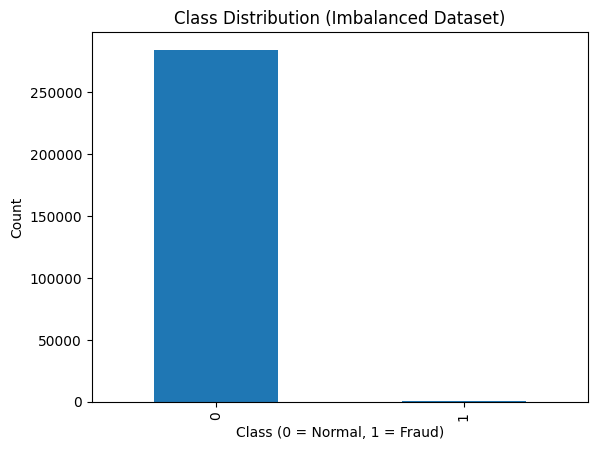

In [32]:
#shows how imbalanced the dataset is
df["Class"].value_counts().plot(kind="bar")

plt.title("Class Distribution (Imbalanced Dataset)")
plt.xlabel("Class (0 = Normal, 1 = Fraud)")
plt.ylabel("Count")
plt.show()

In [33]:
#creates synthetic (fake but realistic) fraud samples
smote = SMOTE(random_state=42)
#applies SMOTE ONLY on training data (avoids data leakage)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

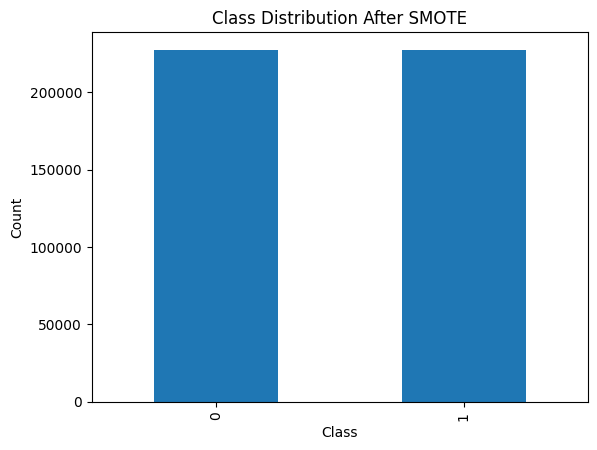

In [34]:
#shows the balanced dataset after SMOTE
y_train_res.value_counts().plot(kind="bar")

plt.title("Class Distribution After SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

### Step 7: Training the Logistic Regression Model

In [35]:
#max_iter=1000 prevents convergence warnings
model = LogisticRegression(max_iter=1000)
model.fit(X_train_res, y_train_res)

LogisticRegression(max_iter=1000)

### Step 8: Making predictions

In [36]:
#predicts the final class labels (0 = normal, 1 = fraud)
y_pred = model.predict(X_test)
#predicts the probability of fraud (used for AUPRC calculation)
y_scores = model.predict_proba(X_test)[:, 1]

### Final Evaluation 

In [37]:
print(classification_report(y_test, y_pred))
precision, recall, _ = precision_recall_curve(y_test, y_scores)
pr_auc = auc(recall, precision)
print("AUPRC:", pr_auc)

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962

AUPRC: 0.7703412904668423


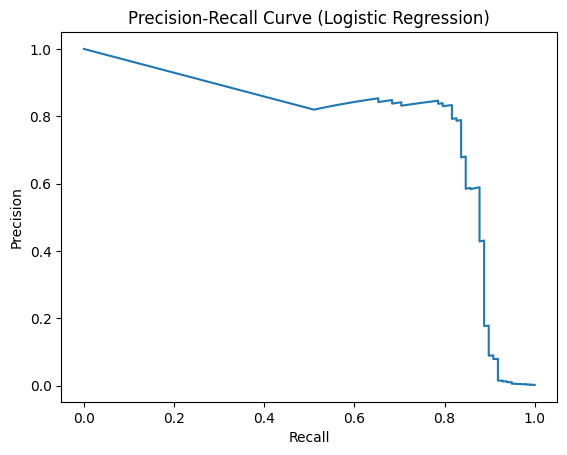

In [38]:
#gets precision and recall values
precision, recall, _ = precision_recall_curve(y_test, y_scores)

#plots the Precision-Recall curve
plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Logistic Regression)")
plt.show()

The Logistic Regression model achieved high recall (0.92) for fraudulent transactions, meaning it successfully identified most fraud cases. However, precision was low (0.06), indicating a high number of false positives. Despite this, the model achieved an AUPRC of 0.77, demonstrating good overall performance in handling the highly imbalanced dataset.